# Inspect SVG generators

Reusable inspection surface for the active `(family, class_name)` generator registry. This notebook runs only sampling and SVG generation: it does not rasterize, calculate OBBs, format labels, or write artifacts.

In [10]:
from pathlib import Path
import sys

import numpy as np
from IPython.display import SVG, display

PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / '06_configs' / 'ontology.yaml').exists()),
    Path.cwd(),
)
SCRIPTS_ROOT = PROJECT_ROOT / '01_scripts'
if str(SCRIPTS_ROOT) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_ROOT))

from generation.core.models import GenerationConfig
from generation.core.sampling import load_sampling_config
from generation.registry import GENERATOR_REGISTRY


In [11]:
sampling_config = load_sampling_config(
    ontology_path=PROJECT_ROOT / '06_configs' / 'ontology.yaml',
    sampling_path=PROJECT_ROOT / '06_configs' / 'symbol_sampling.yaml',
)

print('Active SVG generators:')
for class_key, generator in GENERATOR_REGISTRY.items():
    print(f'  {class_key}: {generator.__name__}')

Active SVG generators:
  ('primitive', 'ch'): generate_ch
  ('primitive', 'slst'): generate_slst
  ('primitive', 'sc'): generate_sc


## Reusable inspection helper

Change `class_key` and `overrides` in the next cell for each generator under inspection. The selected generator must be present in `GENERATOR_REGISTRY`.

In [12]:
def inspect_svg_generator(
    class_key,
    *,
    overrides=None,
    seed=1234,
    generation_config=None,
):
    if class_key not in GENERATOR_REGISTRY:
        raise KeyError(
            f'{class_key!r} is not active. Choose from {list(GENERATOR_REGISTRY)}'
        )

    class_group, class_name = class_key
    spec = sampling_config.resolve(class_group, class_name)
    sample = sampling_config.sample(
        class_group,
        class_name,
        np.random.default_rng(seed),
        seed=seed,
        overrides=overrides or {},
    )
    config = generation_config or GenerationConfig()
    generated = GENERATOR_REGISTRY[class_key](spec, sample, config)

    print(f'Class: {class_group}.{class_name}')
    print(f'Seed: {seed}')
    print(f'Overrides: {overrides or {}}')
    print('Sampled parameters:', sample.parameters)
    print('Derived parameters:', sample.derived)
    print('Components:', sample.components)
    print('Metadata:', generated.metadata)
    display(SVG(data=generated.svg))
    return generated, sample

Class: primitive.ch
Seed: 1234
Overrides: {'shape': 'oval', 'aspect_ratio': 1.75}
Sampled parameters: {'shape': 'oval', 'aspect_ratio': 1.75}
Derived parameters: {}
Components: {}
Metadata: {'class_id': 0, 'class_name': 'ch', 'shape': 'oval', 'aspect_ratio': 1.75, 'canvas': {'width_px': 150, 'height_px': 150}, 'target_visible_px': 90, 'visual_rotation_deg': 20, 'stroke_width_normalized': 4.0}


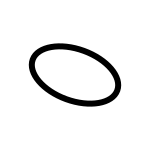

In [16]:
# Select any active registry entry here.
class_key = ('primitive', 'ch')
overrides = {
    'shape': 'oval',
    'aspect_ratio': 1.75,
}

generation_config = GenerationConfig(
    canvas_width_px=150,
    canvas_height_px=150,
    target_visible_px=90,
    rotation_deg=20,
    stroke_width_normalized=4.0,
)

generated, sample = inspect_svg_generator(
    class_key,
    overrides=overrides,
    seed=1234,
    generation_config=generation_config,
)

## Compare cases for the selected generator

Use this cell for a small visual sweep. For classes without sampling overrides, use an empty mapping.


=== Case 1: {'shape': 'oval', 'aspect_ratio': 1.75} ===
Class: primitive.ch
Seed: 2000
Overrides: {'shape': 'oval', 'aspect_ratio': 1.75}
Sampled parameters: {'shape': 'oval', 'aspect_ratio': 1.75}
Derived parameters: {}
Components: {}
Metadata: {'class_id': 0, 'class_name': 'ch', 'shape': 'oval', 'aspect_ratio': 1.75, 'canvas': {'width_px': 150, 'height_px': 150}, 'target_visible_px': 90, 'visual_rotation_deg': 20, 'stroke_width_normalized': 4.0}


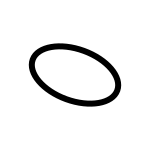


=== Case 2: {'shape': 'circle', 'aspect_ratio': 1.04} ===
Class: primitive.ch
Seed: 2001
Overrides: {'shape': 'circle', 'aspect_ratio': 1.04}
Sampled parameters: {'shape': 'circle', 'aspect_ratio': 1.04}
Derived parameters: {}
Components: {}
Metadata: {'class_id': 0, 'class_name': 'ch', 'shape': 'circle', 'aspect_ratio': 1.04, 'canvas': {'width_px': 150, 'height_px': 150}, 'target_visible_px': 90, 'visual_rotation_deg': 20, 'stroke_width_normalized': 4.0}


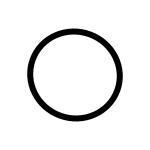

In [18]:
comparison_cases = [
    {'shape': 'oval', 'aspect_ratio': 1.75},
    {'shape': 'circle', 'aspect_ratio': 1.04},
]

for index, case_overrides in enumerate(comparison_cases):
    print(f'\n=== Case {index + 1}: {case_overrides} ===')
    inspect_svg_generator(
        class_key,
        overrides=case_overrides,
        seed=2000 + index,
        generation_config=generation_config,
    )

## Inspect every active generator

This uses each registry entry with its normal sampled values. It is useful as new class generators are added.

In [6]:
for index, class_key in enumerate(GENERATOR_REGISTRY):
    print(f'\n\n######## {class_key} ########')
    inspect_svg_generator(
        class_key,
        seed=3000 + index,
        generation_config=GenerationConfig(),
    )



######## ('primitive', 'ch') ########
Class: primitive.ch
Seed: 3000
Overrides: {}
Sampled parameters: {'shape': 'oval', 'aspect_ratio': 1.1978880778028276}
Derived parameters: {}
Components: {}
Metadata: {'class_id': 0, 'class_name': 'ch', 'shape': 'oval', 'aspect_ratio': 1.1978880778028276, 'canvas': {'width_px': 25, 'height_px': 25}, 'target_visible_px': 15.0, 'visual_rotation_deg': 0.0, 'stroke_width_normalized': 4.0}




######## ('primitive', 'slst') ########
Class: primitive.slst
Seed: 3001
Overrides: {}
Sampled parameters: {'shape': 'circle', 'aspect_ratio': 0.9225533751056806}
Derived parameters: {}
Components: {}
Metadata: {'class_id': 1, 'class_name': 'slst', 'shape': 'circle', 'aspect_ratio': 0.9225533751056806, 'canvas': {'width_px': 25, 'height_px': 25}, 'target_visible_px': 15.0, 'visual_rotation_deg': 0.0, 'stroke_width_normalized': 4.0}




######## ('primitive', 'sc') ########
Class: primitive.sc
Seed: 3002
Overrides: {}
Sampled parameters: {'shape': 'symmetric', 'asymmetry': 0.0}
Derived parameters: {}
Components: {}
Metadata: {'class_id': 2, 'class_name': 'sc', 'shape': 'symmetric', 'asymmetry': 0.0, 'canvas': {'width_px': 25, 'height_px': 25}, 'target_visible_px': 15.0, 'visual_rotation_deg': 0.0, 'stroke_width_normalized': 4.0}
